# Static GMM — Botte & Bao regimes (pmr_paper)

In-sample GMM on standardized 17 factors. Labeling: **sign templates + Hungarian** (old Bloomberg v3 / 5-reg templates).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

def _find_pmr_root() -> Path:
    start = Path.cwd().resolve()
    for parent in [start, *start.parents]:
        if (parent / "scripts" / "paths.py").is_file():
            return parent
    raise FileNotFoundError("Run from inside pmr_paper/")

PROJECT_ROOT = _find_pmr_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.paths import FIGURES_DIR, OUTPUT_DIR, load_features
from scripts.gmm_pipeline import fit_static_gmm, run_walk_forward, static_regime_table, regime_names_from_k
from scripts.plots import plot_regime_history, plot_walk_forward_subset
from scripts.regime_labeling import map_clusters, print_score_diagnostics, sanity_check

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
features = load_features()
print(f"Loaded {features.shape[0]} months x {features.shape[1]} features")


Loaded 663 months x 17 features


## K = 3 regimes


--- Template scores (row=raw cluster, col=regime) ---
 Cluster     Defensive     Inflation        Growth        Assigned
       0        11.802         7.962       -11.677       Inflation
       1         6.745         3.396        -8.936          Growth
       2        11.283         4.353       -15.432       Defensive

 Regime_ID Regime_Name  Months  Mean_SPXT  Std_SPXT  Mean_VIX
         0   Defensive     152   0.005088  0.055952  0.006198
         1   Inflation     199   0.007046  0.045262  0.040588
         2      Growth     312   0.011475  0.035701  0.024514

  SANITY CHECK (K=3)
  [PASS] Oil Crisis / Stagflation        want      Inflation >= 40%  |  got 96%  (Defensive:1, Inflation:22)
  [PASS] Volcker era                     want      Inflation >= 40%  |  got 100%  (Inflation:47)
  [PASS] Black Monday                    want      Defensive >= 25%  |  got 33%  (Defensive:1, Inflation:2)
  [PASS] GFC                             want      Defensive >= 30%  |  got 65%  (Defensive:

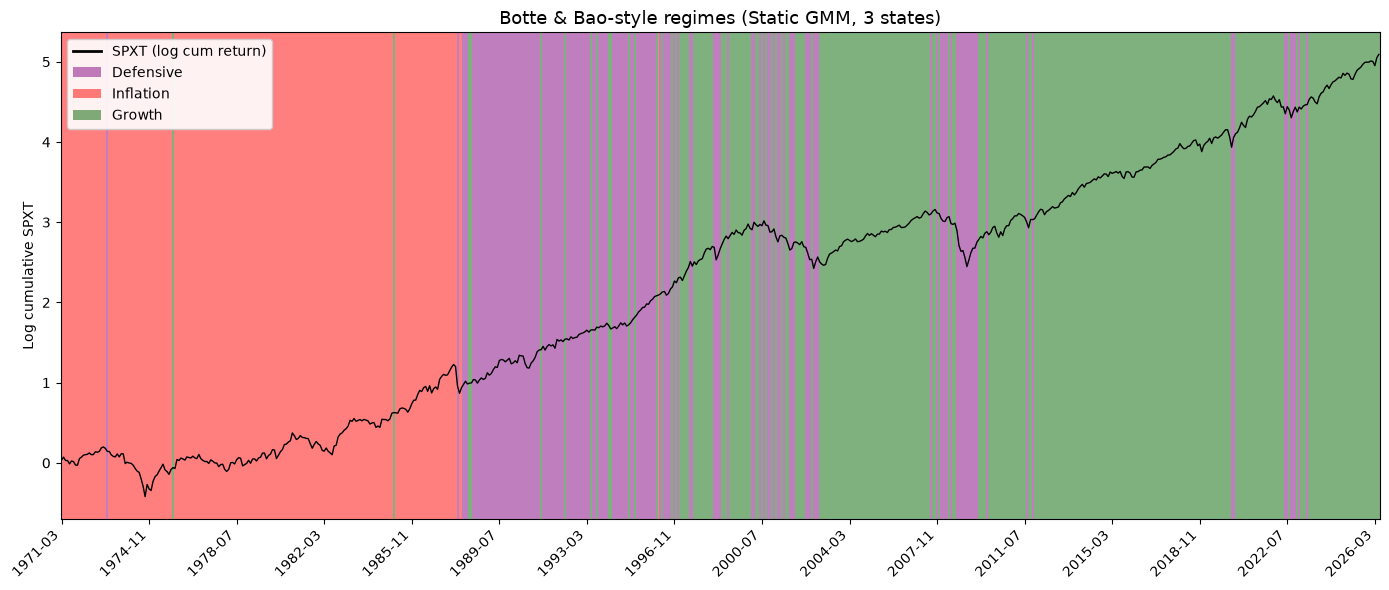

In [2]:
K = 3
gmm3, scaler3, labels3, map3 = fit_static_gmm(features, K)
print_score_diagnostics(gmm3, features.columns, map3, K)
print(static_regime_table(features, labels3, K).to_string(index=False))
sanity_check(labels3, features.index, K)

plot_regime_history(
    features, labels3, K,
    title="Botte & Bao-style regimes (Static GMM, 3 states)",
    save_path=FIGURES_DIR / "static_gmm_k4.png",
)
names4 = regime_names_from_k(3)
pd.DataFrame({"Regime": labels3, "Regime_Name": [names4[r] for r in labels3]}, index=features.index).to_csv(OUTPUT_DIR / "static_gmm_k3.csv")


## K = 4 regimes


--- Template scores (row=raw cluster, col=regime) ---
 Cluster        Crisis     Inflation  Steady State  Walking on Ice        Assigned
       0        12.362         3.538        -7.483        13.443  Walking on Ice
       1        10.690         2.593        -7.121        11.194    Steady State
       2        15.101         5.903        -9.005        14.965       Inflation
       3        27.100         5.449       -22.815        20.412          Crisis

 Regime_ID    Regime_Name  Months  Mean_SPXT  Std_SPXT  Mean_VIX
         0         Crisis      41  -0.041532  0.075376  0.113924
         1      Inflation     187   0.006286  0.041446  0.037235
         2   Steady State     294   0.012419  0.035745  0.012896
         3 Walking on Ice     141   0.018667  0.041052  0.008808

  SANITY CHECK (K=4)
  [PASS] Oil Crisis / Stagflation        want      Inflation >= 40%  |  got 74%  (Crisis:5, Inflation:17, Walking on Ice:1)
  [PASS] Volcker era                     want      Inflation >= 40

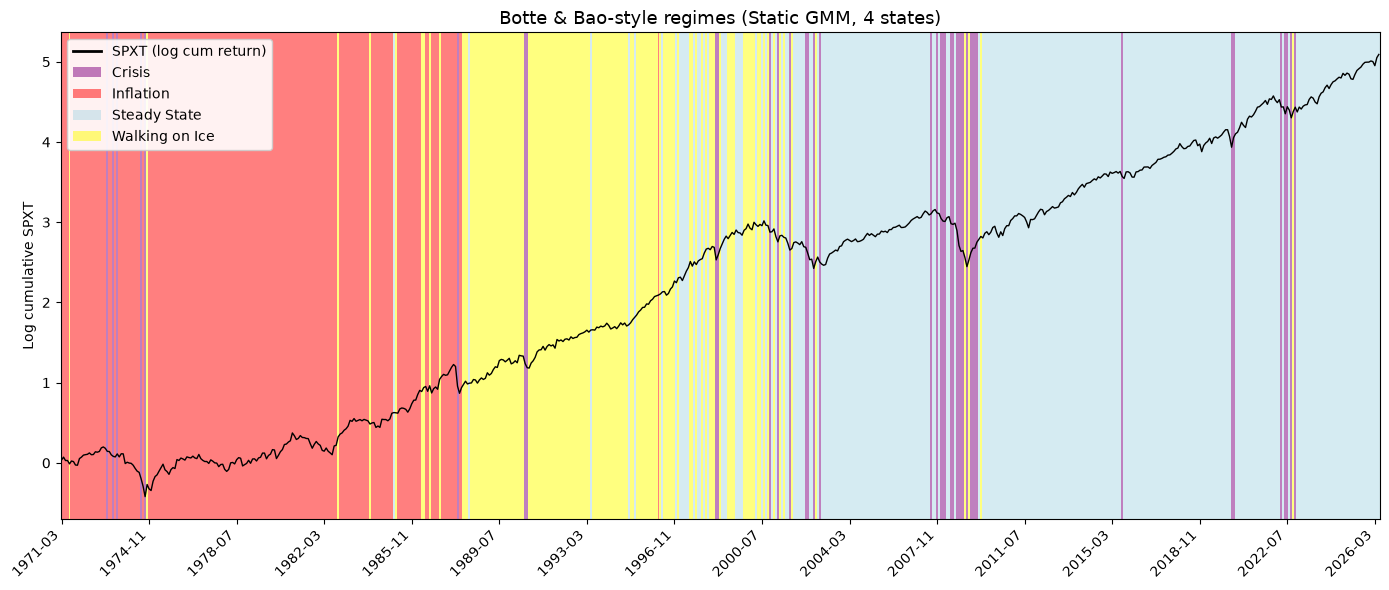

In [3]:
K = 4
gmm4, scaler4, labels4, map4 = fit_static_gmm(features, K)
print_score_diagnostics(gmm4, features.columns, map4, K)
print(static_regime_table(features, labels4, K).to_string(index=False))
sanity_check(labels4, features.index, K)

plot_regime_history(
    features, labels4, K,
    title="Botte & Bao-style regimes (Static GMM, 4 states)",
    save_path=FIGURES_DIR / "static_gmm_k4.png",
)
names4 = regime_names_from_k(4)
pd.DataFrame({"Regime": labels4, "Regime_Name": [names4[r] for r in labels4]}, index=features.index).to_csv(OUTPUT_DIR / "static_gmm_k4.csv")


## K = 5 regimes (+ Bull Market)


--- Template scores (row=raw cluster, col=regime) ---
 Cluster        Crisis     Inflation  Steady State  Walking on Ice   Bull Market        Assigned
       0         9.196         7.067        -4.822        29.828       -16.351  Walking on Ice
       1         7.980         5.044       -15.167         8.475       -17.506       Inflation
       2         3.162         3.681         0.649        15.676        -5.899    Steady State
       3         4.617         3.584        -5.593        10.862        -9.813     Bull Market
       4        19.264         6.757       -35.213         7.513       -35.020          Crisis



,Regime_ID,Regime_Name,Months,Mean_SPXT,Std_SPXT,Mean_VIX
0,0,Crisis,77,-0.031184,0.067306,0.129326
1,1,Inflation,222,0.002898,0.041730,0.022960
2,2,Steady State,87,0.025398,0.031573,-0.007392
3,3,Walking on Ice,68,0.036587,0.043547,0.014332
4,4,Bull Market,209,0.013475,0.024601,0.006127



  SANITY CHECK (K=5)
  [PASS] Oil Crisis / Stagflation        want      Inflation >= 40%  |  got 61%  (Crisis:7, Inflation:14, Walking on Ice:1, Bull Market:1)
  [PASS] Volcker era                     want      Inflation >= 40%  |  got 40%  (Crisis:3, Inflation:19, Steady State:1, Walking on Ice:23, Bull Market:1)
  [PASS] Black Monday                    want         Crisis >= 25%  |  got 67%  (Crisis:2, Inflation:1)
  [PASS] GFC                             want         Crisis >= 30%  |  got 55%  (Crisis:11, Inflation:7, Steady State:2)
  [PASS] COVID crash                     want         Crisis >= 33%  |  got 100%  (Crisis:2)
  [FAIL] Dot-com / late 90s              want    Bull Market >= 30%  |  got 29%  (Crisis:3, Inflation:15, Steady State:21, Walking on Ice:3, Bull Market:17)
  [FAIL] Post-GFC expansion              want   Steady State >= 35%  |  got 9%  (Crisis:8, Inflation:26, Steady State:9, Bull Market:52)
  Result: SOME CHECKS FAILED


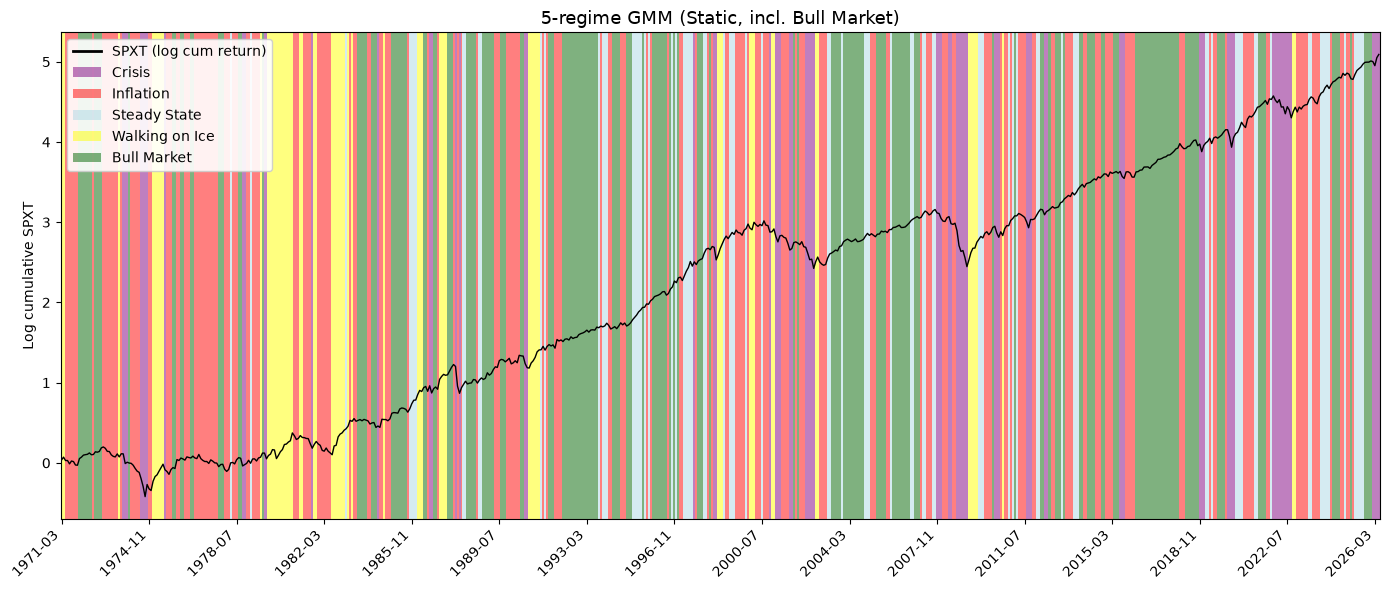

In [4]:
K = 5
gmm5, scaler5, labels5, map5 = fit_static_gmm(features, K)
print_score_diagnostics(gmm5, features.columns, map5, K)
display(static_regime_table(features, labels5, K))
sanity_check(labels5, features.index, K)

plot_regime_history(
    features, labels5, K,
    title="5-regime GMM (Static, incl. Bull Market)",
    save_path=FIGURES_DIR / "static_gmm_k5.png",
)
names5 = regime_names_from_k(5)
pd.DataFrame({"Regime": labels5, "Regime_Name": [names5[r] for r in labels5]}, index=features.index).to_csv(OUTPUT_DIR / "static_gmm_k5.csv")
